# Visualizing Housing Data

## Research Question
> Are property prices in Mexico more influenced by property size or by location?

## What This Notebook Does
In Lesson 1 we cleaned the data. Now we visualize it to reveal patterns 
that summary statistics alone cannot show:
- Distribution shape of price and area (histograms)
- Price differences across property types and states (boxplots)
- Relationship between size and price (scatterplots)
- Whether that relationship changes by location (small multiples)

## 1. Setup and Data Loading

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean dataset 
df = pd.read_csv("../data/mexico-real-estate-combined-clean.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1736, 6)
Columns: ['property_type', 'state', 'lat', 'lon', 'area_m2', 'price_usd']


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


## 2. Univariate Analysis — Understanding One Variable at a Time

Before comparing variables we look at each one individually.
A histogram shows us the shape, spread, and skew of a distribution.

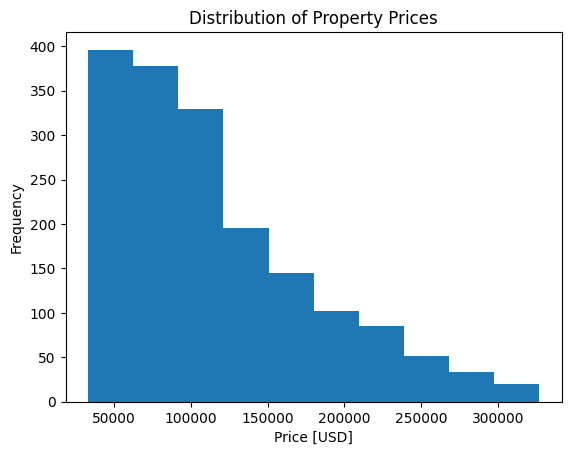

In [23]:
# Histogram of price_usd
fig, ax = plt.subplots()
ax.hist(df["price_usd"])
fig.savefig("../images/01_price_distribution.png", bbox_inches="tight", dpi=150)

ax.set_xlabel("Price [USD]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Prices")
plt.show()

**Finding:** Price is strongly right-skewed. Most properties are priced 
between $30,000–$130,000 but a few luxury properties extend the tail 
to $300,000+. This means the mean (~$115,000) overstates what a 
typical buyer pays — the median (~$97,000) is more honest.

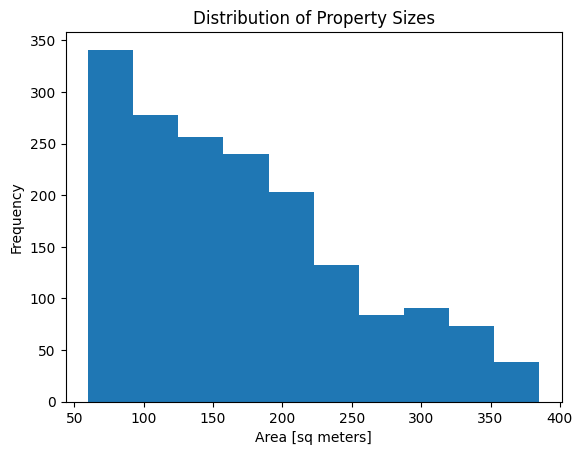

In [24]:
# Histogram of area_m2
fig, ax = plt.subplots()
ax.hist(df["area_m2"])
fig.savefig("../images/02_area_distribution.png", bbox_inches="tight", dpi=150)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes")
plt.show()

**Finding:** Area is also right-skewed. Most properties are 50–150 m² 
but a few large estates stretch the tail to 1,000+ m². 
Both variables need outlier removal before scatterplot analysis.

## 3. Bivariate Analysis — Categorical vs Numerical

Boxplots let us compare a numerical variable across categories.
Each box shows the median, IQR, and outliers for that group.

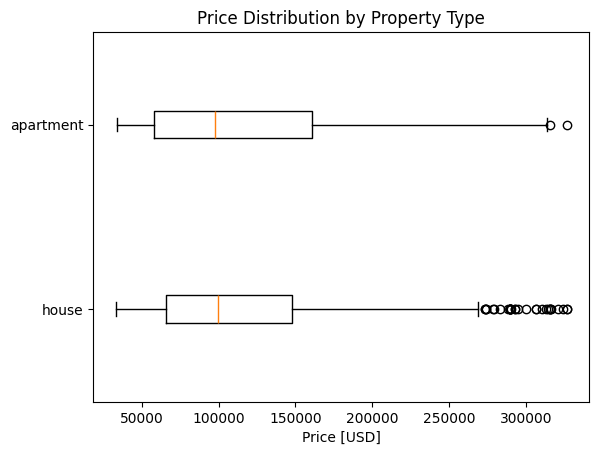

In [25]:
# Boxplot: price by property type
prop_types = df["property_type"].unique()
data_by_type = [df[df["property_type"] == pt]["price_usd"] for pt in prop_types]

fig, ax = plt.subplots()
ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)
fig.savefig("../images/03_price_by_property_type.png", bbox_inches="tight", dpi=150)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")
plt.show()

**Finding:** Houses and apartments have similar median prices (~$100,000). 
However houses have a longer right tail — more high-value outliers. 
The similar medians are misleading: apartments are smaller so they are 
actually more expensive per square meter.

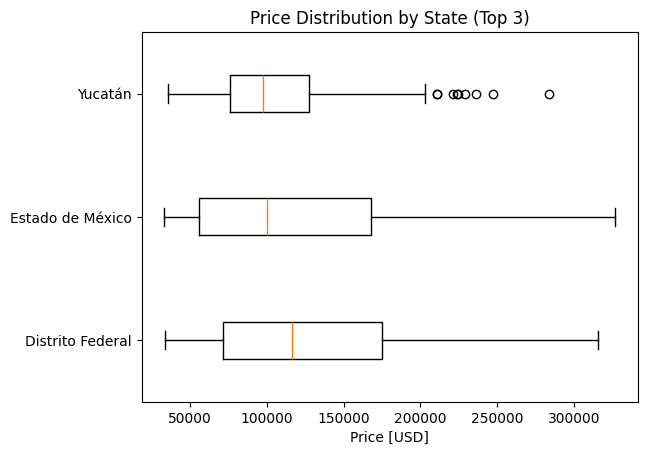

In [26]:
# Boxplot: price by top 3 states
selected_states = df["state"].value_counts().head(3).index.tolist()
data_by_state = [df[df["state"] == state]["price_usd"] for state in selected_states]

fig, ax = plt.subplots()
ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)
fig.savefig("../images/04_price_by_state.png", bbox_inches="tight", dpi=150)

ax.set_title("Price Distribution by State (Top 3)")
ax.set_xlabel("Price [USD]")
plt.show()

**Finding:** Location matters significantly:
- **Distrito Federal** — highest median price, widest spread (diverse market)
- **Estado de México** — moderate prices, influenced by proximity to DF
- **Yucatán** — lowest and most consistent prices, with luxury outliers

This is the first evidence that location drives price differences.

## 4. Bivariate Analysis — Numerical vs Numerical

Scatterplots show whether two numerical variables move together.
We first plot the raw data, then remove outliers to reveal the true pattern.

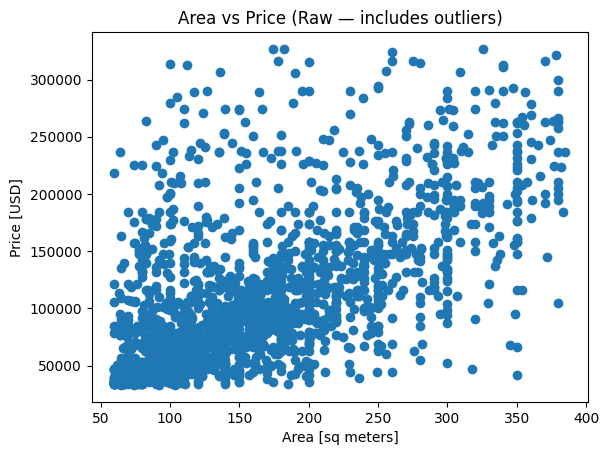

In [27]:
# Raw scatterplot
fig, ax = plt.subplots()
ax.scatter(x=df["area_m2"], y=df["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs Price (Raw — includes outliers)")
plt.show()

**Finding:** The raw plot is compressed — a few extreme properties 
squeeze everything else into the bottom-left corner. 
Outlier removal is needed to see the real pattern.

Original : 1,736 rows
Cleaned  : 1,365 rows
Removed  : 371 rows


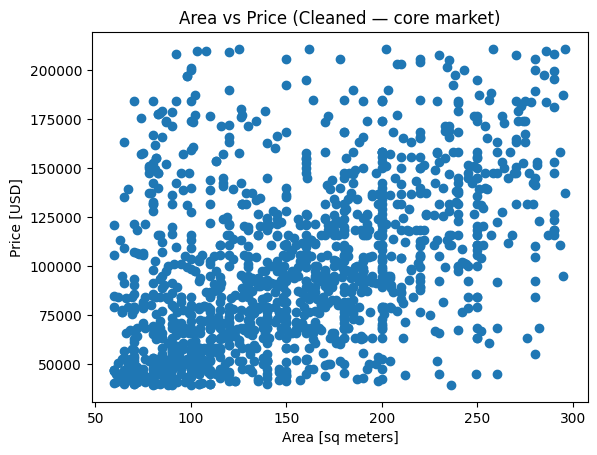

In [28]:
# Remove outliers using quantiles
lower_cut = 0.05
upper_cut = 0.90

df_clean = df[
    (df["price_usd"] > df["price_usd"].quantile(lower_cut)) &
    (df["price_usd"] < df["price_usd"].quantile(upper_cut)) &
    (df["area_m2"]  < df["area_m2"].quantile(upper_cut))
]

print(f"Original : {len(df):,} rows")
print(f"Cleaned  : {len(df_clean):,} rows")
print(f"Removed  : {len(df) - len(df_clean):,} rows")

# Cleaned scatterplot
fig, ax = plt.subplots()
fig.savefig("../images/plot_name.png", bbox_inches="tight", dpi=150)
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
fig.savefig("../images/05_area_vs_price_clean.png", bbox_inches="tight", dpi=150)
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs Price (Cleaned — core market)")
plt.show()

**Finding:** After removing the bottom 5% and top 10% of prices 
and the top 10% of areas, the positive relationship between 
size and price becomes clearly visible. Larger properties 
generally cost more — but there is significant scatter, 
suggesting other factors (like location) also matter.

## 5. Adding a Trendline

`seaborn.regplot()` adds a regression line and confidence band.
The slope tells us the average price increase per extra m².
The width of the band tells us how confident we are in that estimate.

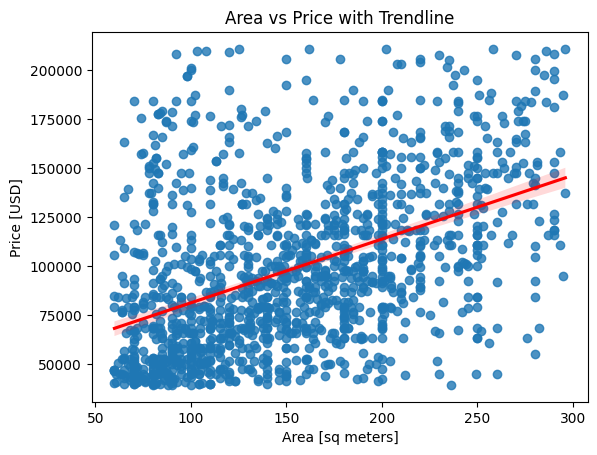

In [29]:
fig, ax = plt.subplots()
fig.savefig("../images/plot_name.png", bbox_inches="tight", dpi=150)
fig.savefig("../images/06_trendline.png", bbox_inches="tight", dpi=150)

sns.regplot(
    data=df_clean,
    x="area_m2",
    y="price_usd",
    line_kws={"color": "red"},
    ax=ax
)
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs Price with Trendline")
plt.show()

**Finding:** The trendline confirms a positive relationship — 
each additional m² adds roughly $700 to the price on average. 
The wide confidence band at larger sizes tells us there is 
less data there and more uncertainty in that estimate.
The increasing spread of points (heteroscedasticity) shows 
that size predicts price better for small properties than large ones.

## 6. Which States Have the Highest Prices?

Before comparing relationships across states we first identify 
which states are most expensive on average using groupby.

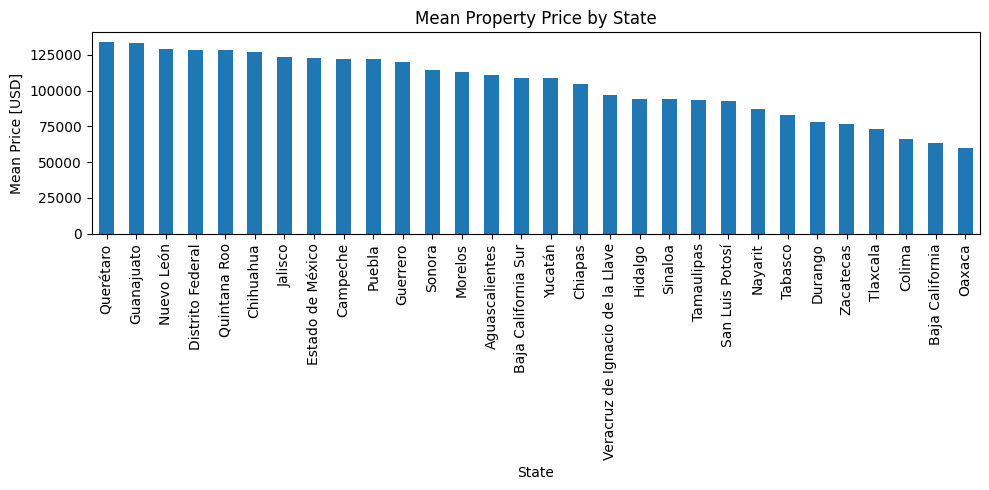

In [30]:
mean_price_by_state = (
    df.groupby("state")["price_usd"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.savefig("../images/plot_name.png", bbox_inches="tight", dpi=150)
mean_price_by_state.plot(kind="bar", ax=ax)
fig.savefig("../images/07_mean_price_by_state.png", bbox_inches="tight", dpi=150)
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean Property Price by State")
plt.tight_layout()
plt.show()

**Finding:** Distrito Federal has the highest mean price by a 
significant margin — confirming the location effect we saw 
in the boxplot. Geography clearly matters.

## 7. Small Multiples — Does the Relationship Change by Location?

This is the key question: does size predict price equally well 
in every state, or does the relationship change by location?
Small multiples show the same scatterplot for each of the top 3 states.

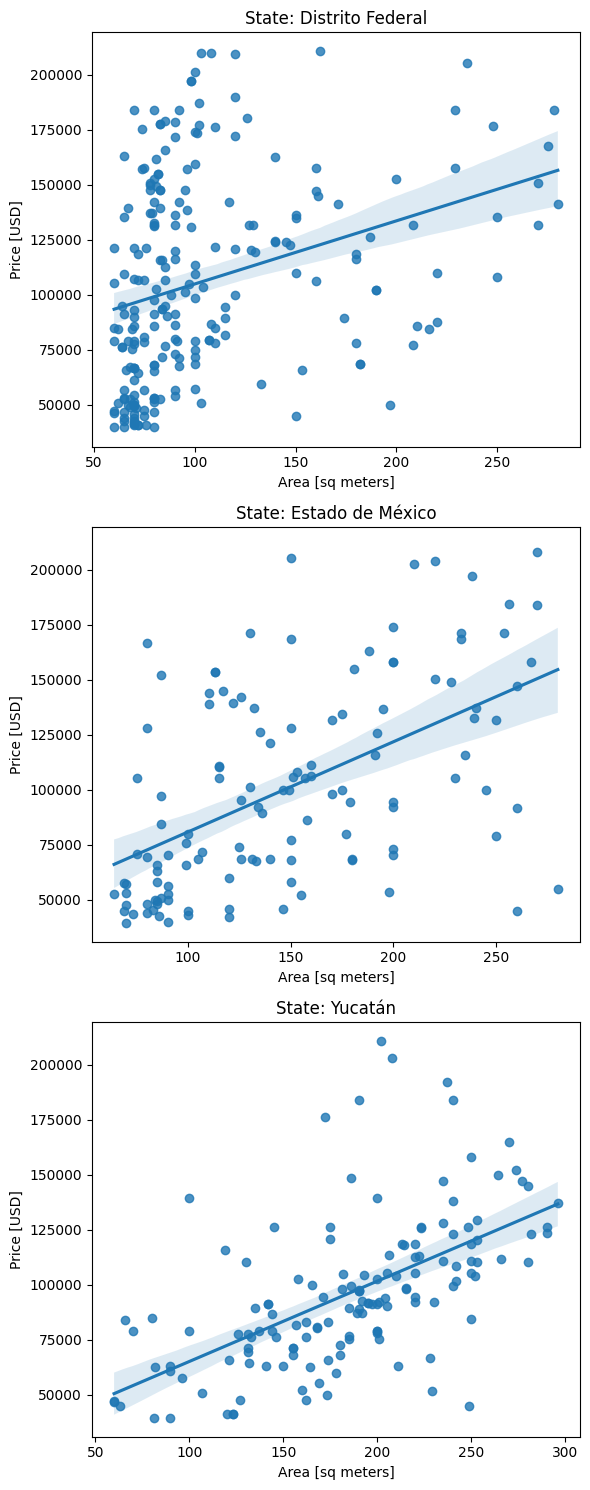

In [31]:
selected_states = df["state"].value_counts().head(3).index.tolist()
df_states = df_clean[df_clean["state"].isin(selected_states)]

fig, axes = plt.subplots(3, 1, figsize=(6, 15), sharey=True)
fig.savefig("../images/plot_name.png", bbox_inches="tight", dpi=150)
fig.savefig("../images/08_small_multiples.png", bbox_inches="tight", dpi=150)

for ax, state in zip(axes, selected_states):
    subset = df_states[df_states["state"] == state]
    sns.regplot(
        data=subset,
        x="area_m2",
        y="price_usd",
        color="tab:blue",
        ax=ax
    )
    ax.set_title(f"State: {state}")
    ax.set_xlabel("Area [sq meters]")
    ax.set_ylabel("Price [USD]")

plt.tight_layout()
plt.show()

**Finding — The most important result of this lesson:**

The size-price relationship looks completely different across states:

- **Yucatán:** Steepest slope and narrowest confidence band — 
  size is a strong, reliable predictor of price here
- **Estado de México:** Moderate positive slope — size predicts 
  price but with more uncertainty
- **Distrito Federal:** Nearly flat line and wide band — 
  size barely explains price in Mexico City. 
  Location within the city (neighbourhood, transit access) 
  matters far more than raw size

**Conclusion:** A single national correlation number would hide 
these differences entirely. Location does not just change the 
price level — it changes how much size matters at all.

## Key Findings Summary

| Finding | Evidence |
|---|---|
| Price and area are both right-skewed | Histograms — long tails to the right |
| Property type barely affects price | Boxplot — similar medians for houses and apartments |
| Location significantly affects price | Boxplot — DF median much higher than Yucatán |
| Size and price are positively related | Scatterplot + trendline — clear upward slope |
| The size-price relationship varies by state | Small multiples — flat in DF, steep in Yucatán |

**Next step:** Lesson 3 will quantify these relationships 
with Pearson correlation coefficients and investigate 
whether the national correlation masks state-level differences.